1. LOGISTIC REGRESSION

1.A. Loads merged data, separates features/target, and creates train–test split

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

india_df = pd.read_csv("../data/processed/india_cleaned_aligned.csv")
us_df = pd.read_csv("../data/processed/us_cleaned_aligned.csv")

centralized_df = pd.concat([india_df, us_df], axis=0).reset_index(drop=True)

X = centralized_df.drop(columns=["Diabetes_binary"])
y = centralized_df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


1.B. Imports required class and defines the Logistic Regression

In [2]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [3]:
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

1.C. Generates class predictions and probability scores for evaluation

In [4]:
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

1.D. Evaluates baseline performance using accuracy and detailed class-wise metrics

In [5]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.696920552176851
              precision    recall  f1-score   support

           0       0.94      0.69      0.79     44185
           1       0.29      0.74      0.42      7610

    accuracy                           0.70     51795
   macro avg       0.62      0.72      0.61     51795
weighted avg       0.84      0.70      0.74     51795



1.E. Shows how many predictions were correct and wrong for each class

In [6]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[30429 13756]
 [ 1942  5668]]


1.F. Calculates how well the model separates diabetic vs non-diabetic cases

In [7]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(y_test, y_proba_lr)
print("ROC-AUC Score:", lr_auc)

ROC-AUC Score: 0.7871501156066871


1.G. Draws a graph that shows how well the model separates diabetic and non-diabetic cases

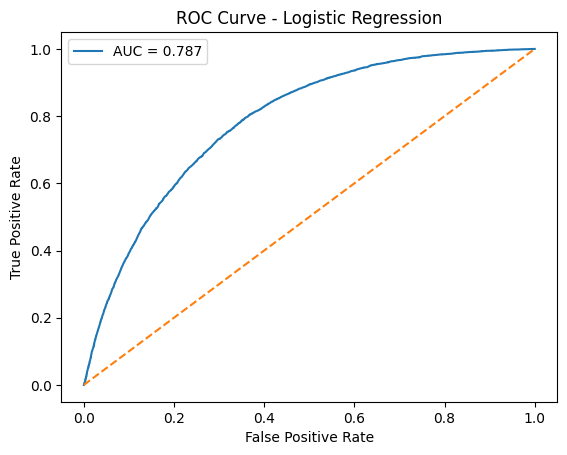

In [8]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_lr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {lr_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.savefig(save_path + "logistic_regression_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

2. RANDOM FOREST 

2.A. Defines the Random Forest model with fixed randomness for repeatable results

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.45
y_pred_rf = (y_proba_rf >= threshold).astype(int)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

2.B. Checks baseline accuracy and detailed class-wise performance

In [10]:

from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7188724780384207
              precision    recall  f1-score   support

           0       0.92      0.73      0.82     44185
           1       0.29      0.63      0.40      7610

    accuracy                           0.72     51795
   macro avg       0.61      0.68      0.61     51795
weighted avg       0.83      0.72      0.76     51795



2.C. Shows how many predictions are correct and wrong for each class.

In [11]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[32432 11753]
 [ 2808  4802]]


2.D. Measures how well Random Forest separates diabetic vs non-diabetic cases.

In [12]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, y_proba_rf)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.7431684395900227


2.E. Plots the ROC curve for Random Forest and saves it for evaluation/paper use

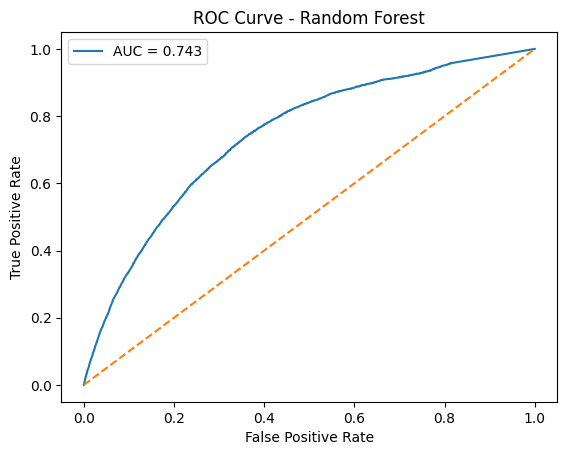

In [13]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {rf_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig(save_path + "random_forest_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

3. XGBOOST

In [14]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

3.A. Defines the XGBoost model with controlled randomness for repeatable runs

In [15]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

3.B. Trains the XGBoost model on the centralized training dataset.

In [16]:
xgb_model.fit(X_train, y_train)

c:\Users\Gautam Bijarniya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:09:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

3.C. Generates predictions and probability scores for evaluation.

In [17]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

3.D Measures how well Random Forest separates diabetic vs non-diabetic cases.

In [18]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[30277 13908]
 [ 1743  5867]]


3.E. Measures how well XGBoost separates diabetic vs non-diabetic cases.

In [19]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(y_test, y_proba_xgb)
print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.8037698055169721


3.E. Plots the ROC curve for XGBoost and saves it to the evaluation folder.

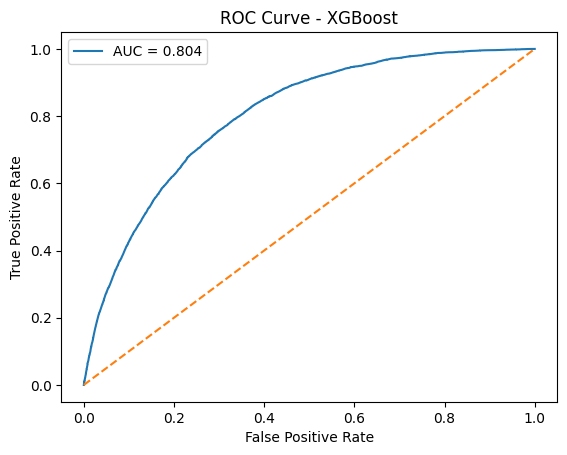

In [20]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {xgb_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.savefig(save_path + "xgboost_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

4. BUILD VOTING

4.A. Defines a soft voting classifier

In [21]:
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(
    estimators=[
        ("lr", lr_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft",
    weights=[1, 1, 2],   # Give XGBoost more weight
    n_jobs=-1
)

4.B. Trains the soft voting 

In [22]:
voting_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 1, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


4.C. Generates final class predictions and probability scores for evaluation

In [23]:
y_proba_vote = voting_model.predict_proba(X_test)[:, 1]
y_pred_vote = (y_proba_vote >= 0.5).astype(int)

4.D. Evaluates overall accuracy

In [24]:
from sklearn.metrics import accuracy_score, classification_report

vote_accuracy = accuracy_score(y_test, y_pred_vote)
print("Voting Accuracy:", vote_accuracy)

print(classification_report(y_test, y_pred_vote))

Voting Accuracy: 0.7158219905396274
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     44185
           1       0.31      0.74      0.43      7610

    accuracy                           0.72     51795
   macro avg       0.62      0.73      0.62     51795
weighted avg       0.85      0.72      0.76     51795



4.E. Shows how many healthy and diabetic cases were correctly and incorrectly predicted

In [25]:
from sklearn.metrics import confusion_matrix

cm_vote = confusion_matrix(y_test, y_pred_vote)
print("Confusion Matrix:\n", cm_vote)

Confusion Matrix:
 [[31430 12755]
 [ 1964  5646]]


4.F.  Measures how well the ensemble separates diabetic vs non-diabetic cases.

In [26]:
from sklearn.metrics import roc_auc_score

vote_auc = roc_auc_score(y_test, y_proba_vote)
print("Voting ROC-AUC:", vote_auc)

Voting ROC-AUC: 0.7988866813572191


4.G. Plots the ROC curve

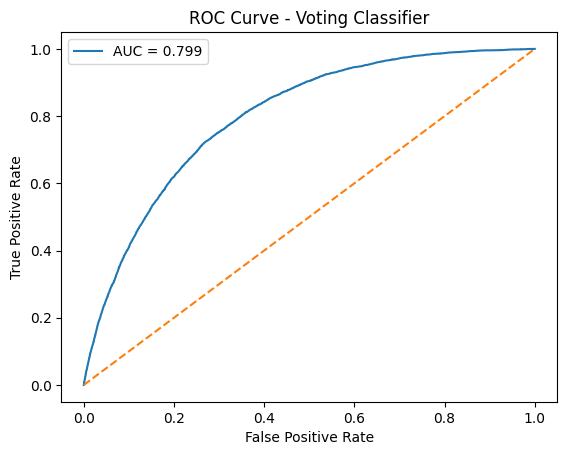

In [27]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_vote)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {vote_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Voting Classifier")
plt.legend()

plt.savefig(save_path + "voting_classifier_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

accuracy_list = []
auc_list = []
recall_list = []
f1_list = []

sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(X, y):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=None
    )
    
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    

In [29]:
accuracy_list.append(accuracy_score(y_test, y_pred))
auc_list.append(roc_auc_score(y_test, y_proba))
recall_list.append(recall_score(y_test, y_pred))
f1_list.append(f1_score(y_test, y_pred))

print("Accuracy: {:.3f} ± {:.3f}".format(np.mean(accuracy_list), np.std(accuracy_list)))
print("ROC-AUC: {:.3f} ± {:.3f}".format(np.mean(auc_list), np.std(auc_list)))
print("Recall: {:.3f} ± {:.3f}".format(np.mean(recall_list), np.std(recall_list)))
print("F1-score: {:.3f} ± {:.3f}".format(np.mean(f1_list), np.std(f1_list)))

Accuracy: 0.697 ± 0.000
ROC-AUC: 0.804 ± 0.000
Recall: 0.776 ± 0.000
F1-score: 0.429 ± 0.000


Unified Plots

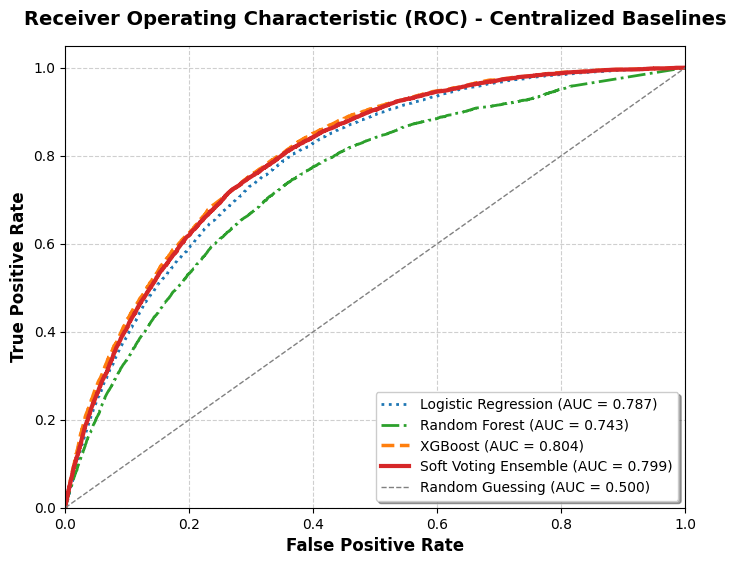

In [30]:
# reconstructed pristine X_test & y_test to prevent CV loop bleed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Recalculate probabilities strictly on the true test set
fresh_proba_lr = lr_model.predict_proba(X_test)[:, 1]
fresh_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fresh_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
fresh_proba_vote = voting_model.predict_proba(X_test)[:, 1]

# Get fresh auc scores
fresh_auc_lr = roc_auc_score(y_test, fresh_proba_lr)
fresh_auc_rf = roc_auc_score(y_test, fresh_proba_rf)
fresh_auc_xgb = roc_auc_score(y_test, fresh_proba_xgb)
fresh_auc_vote = roc_auc_score(y_test, fresh_proba_vote)

fpr_lr, tpr_lr, _ = roc_curve(y_test, fresh_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, fresh_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, fresh_proba_xgb)
fpr_vote, tpr_vote, _ = roc_curve(y_test, fresh_proba_vote)

plt.figure(figsize=(8, 6))
plt.style.use("default")

plt.plot(fpr_lr, tpr_lr, color="#1f77b4", linestyle=":", linewidth=2, label=f"Logistic Regression (AUC = {fresh_auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, color="#2ca02c", linestyle="-.", linewidth=2, label=f"Random Forest (AUC = {fresh_auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, color="#ff7f0e", linestyle="--", linewidth=2.5, label=f"XGBoost (AUC = {fresh_auc_xgb:.3f})")
plt.plot(fpr_vote, tpr_vote, color="#d62728", linestyle="-", linewidth=3, label=f"Soft Voting Ensemble (AUC = {fresh_auc_vote:.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random Guessing (AUC = 0.500)")

plt.title("Receiver Operating Characteristic (ROC) - Centralized Baselines", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("False Positive Rate", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="bold")
plt.legend(loc="lower right", fontsize=10, frameon=True, shadow=True)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

save_path_pdf = "../4_evaluation_and_paper/plots/unified_roc_curve.pdf"
save_path_png = "../4_evaluation_and_paper/plots/unified_roc_curve.png"

plt.savefig(save_path_pdf, format="pdf", dpi=300, bbox_inches="tight")
plt.savefig(save_path_png, format="png", dpi=300, bbox_inches="tight")

plt.show()
